In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from pathlib import Path

In [2]:
rawrecipes = pd.read_csv('/Users/phuongnguyen/Documents/cours_BGD_Telecom_Paris_2024/Kit_Big_Data/dataset/RAW_recipes.csv')

In [12]:
nutrition = pd.Series(rawrecipes['nutrition'], columns=['calories', 'total_fat', 'sugar', 'sodium', 'protein', 'saturated_fat', 'carbohydrates'])

TypeError: Series.__init__() got an unexpected keyword argument 'columns'

In [15]:
rawrecipes['nutrition'][0]

'[51.5, 0.0, 13.0, 0.0, 2.0, 0.0, 4.0]'

In [20]:
import re
def get_value_from_string(string):
    # Utilisation de re.findall pour extraire les nombres (flottants et entiers)
    numbers = re.findall(r'\d+\.\d+|\d+', string)

    # Convertir les nombres extraits en float ou int
    numbers = [float(num) if '.' in num else int(num) for num in numbers]

    return numbers

get_value_from_string(rawrecipes['nutrition'][0])

[51.5, 0.0, 13.0, 0.0, 2.0, 0.0, 4.0]

In [22]:
nutrition = rawrecipes['nutrition'].apply(get_value_from_string)
type(nutrition)

pandas.core.series.Series

In [23]:
nutrition = pd.DataFrame(nutrition.tolist(), columns=['calories', 'total_fat', 'sugar', 'sodium', 'protein', 'saturated_fat', 'carbohydrates'])

In [24]:
nutrition.head()

,calories,total_fat,sugar,sodium,protein,saturated_fat,carbohydrates
0,51.5,0.0,13.0,0.0,2.0,0.0,4.0
1,173.4,18.0,0.0,17.0,22.0,35.0,1.0
2,269.8,22.0,32.0,48.0,39.0,27.0,5.0
3,368.1,17.0,10.0,2.0,14.0,8.0,20.0
4,352.9,1.0,337.0,23.0,3.0,0.0,28.0


In [26]:
scores = pd.Dataframe(size=(nutrition.shape))

AttributeError: module 'pandas' has no attribute 'Dataframe'

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from pathlib import Path

recipe_data = pd.read_csv('/Users/phuongnguyen/Documents/cours_BGD_Telecom_Paris_2024/Kit_Big_Data/dataset/RAW_recipes.csv', sep = ',')
nutriscore_grille = pd.read_csv('/Users/phuongnguyen/Documents/cours_BGD_Telecom_Paris_2024/Kit_Big_Data/scripts/nutrient_table.csv', sep = ';')
nutritioncolname = ['calories', 'total_fat', 'sugar', 'sodium', 'protein', 'saturated_fat', 'carbohydrates']
configs = {'nutritioncolname': nutritioncolname}
#print(recipe_data.head())
#energie = 2000
#portion_energie = 800

# extraction des informations nutritionnelles de la colonne 'nutrition' en créant 7 nouvelles colonnes
# les éléments de la colonne 'nutrition' sot de type string et doivent être ensuite convertis en valeurs numériques
def nutrition_info_extraction(data):
    # Vérifier si la colonne 'nutrition' existe
    if 'nutrition' not in data.columns:
        raise ValueError("La colonne 'nutrition' est absente du DataFrame")
    
    # Diviser la colonne 'nutrition' en 7 nouvelles colonnes
    nutrition_split = data['nutrition'].str.split(",", expand=True)

    # Vérifier si la division a produit 7 colonnes
    if nutrition_split.shape[1] != 7:
        raise ValueError("La colonne 'nutrition' ne contient pas 7 éléments séparés par des virgules")
    
    # Assigner les nouvelles colonnes
    data[['calories', 'total_fat_%', 'sugar_%', 'sodium_%', 'protein_%', 'sat_fat_%', 'carbs_%']] = nutrition_split
    
    # Nettoyer les données extraites
    data['calories'] = data['calories'].apply(lambda x: x.replace('[', ''))
    data['carbs_%'] = data['carbs_%'].apply(lambda x: x.replace(']',''))
    
    # Convertir les colonnes en types numériques
    for col in ['calories', 'total_fat_%', 'sugar_%', 'sodium_%', 'protein_%', 'sat_fat_%', 'carbs_%']:
        data[col] = pd.to_numeric(data[col], errors='coerce')

    return data

class datatools:
    def get_value_from_string(string):
    # Utilisation de re.findall pour extraire les nombres (flottants et entiers)
        numbers = re.findall(r"\d+\.\d+|\d+", string)
        # Convertir les nombres extraits en float ou int
        numbers = [float(num) if '.' in num else int(num) for num in numbers]
        return numbers


class preprocessing:
    def __init__(self, path, confgis):
        self.rawdata = pd.read_csv(path, sep = ',')
        self.configs = configs
        self.formatdata = self.get_formatted_nutrition()
        self.normaldata = self.set_dv_normalisation()
    
    def get_raw_nutrition(self):
        return self.rawdata['nutrition']
    
    def get_formatted_nutrition(self):
        data = self.get_raw_nutrition()
        formatted_data = data.apply(datatools.get_value_from_string)
        table = pd.DataFrame(formatted_data.tolist(), columns=self.configs['nutritioncolname'])
        return table
    
    def set_dv_normalisation(self):
        # ajouter une colonne dv_calories_% pour normaliser les valeurs nutritionnelles 
        # par rapport aux apports journaliers recommandés
        dv_calories = self.configs['dv_calories']
        fttable = self.formatdata
        table = pd.DataFrame()
        table['dv_calories_%'] = fttable['calories'] * 100 / dv_calories
        for col in self.configs['nutritioncolname'][1:]:
            table[f'dv_{col}'] = fttable[col] * dv_calories /fttable['calories']
        return table
    
    
    

In [2]:
path = '/Users/phuongnguyen/Documents/cours_BGD_Telecom_Paris_2024/Kit_Big_Data/dataset/RAW_recipes.csv'
configs = {'nutritioncolname':['calories', 'total_fat_%', 'sugar_%', 'sodium_%', 'protein_%', 'sat_fat_%', 'carbs_%'],
            'dv_calories' : 2000
}
nutrition_table = preprocessing(path, configs).formatdata




In [3]:
nutrition_table

,calories,total_fat_%,sugar_%,sodium_%,protein_%,sat_fat_%,carbs_%
0,51.5,0.0,13.0,0.0,2.0,0.0,4.0
1,173.4,18.0,0.0,17.0,22.0,35.0,1.0
2,269.8,22.0,32.0,48.0,39.0,27.0,5.0
3,368.1,17.0,10.0,2.0,14.0,8.0,20.0
4,352.9,1.0,337.0,23.0,3.0,0.0,28.0
...,...,...,...,...,...,...,...
231632,415.2,26.0,34.0,26.0,44.0,21.0,15.0
231633,14.8,0.0,2.0,58.0,1.0,0.0,1.0
231634,59.2,6.0,2.0,3.0,6.0,5.0,0.0
231635,188.0,11.0,57.0,11.0,7.0,21.0,9.0


<Axes: >

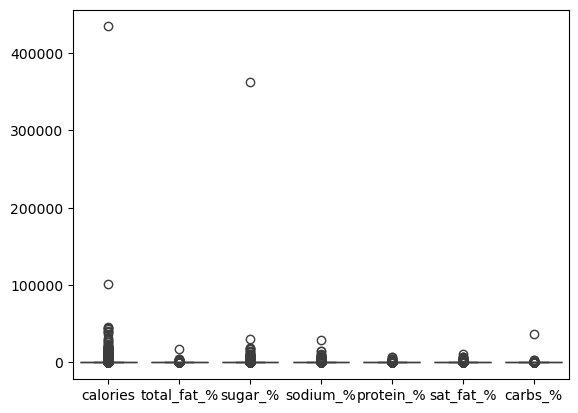

In [4]:
import seaborn as sns

sns.boxplot(data=nutrition_table)

[     8      8     24 ... 231583 231583 231583]


Text(0.5, 1.0, 'Boxplot des valeurs nutritionnelles sans les outliers')

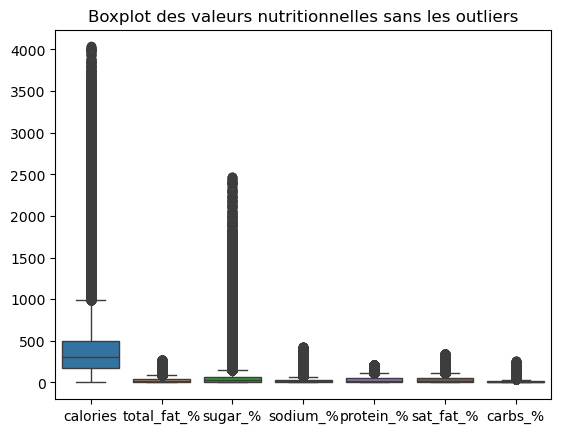

In [5]:
from scipy import stats

# Z-score pour chaque variable du DataFrame
z_scores = np.abs(stats.zscore(nutrition_table))

# Détection des outliers avec un seuil de Z-score > 3
outliers_zscore = np.where(z_scores > 3)[0]
print(outliers_zscore)

pp = sns.boxplot(data = nutrition_table.drop(outliers_zscore))
pp.set_title('Boxplot des valeurs nutritionnelles sans les outliers')
# nutrition_table = nutrition_table.drop(outliers_zscore)

In [50]:
print(z_scores)

        calories  total_fat_%   sugar_%  sodium_%  protein_%  sat_fat_%  \
0       0.355081     0.463770  0.089112  0.228457   0.558928   0.464080   
1       0.252618     0.232404  0.105361  0.099631   0.216886   0.107793   
2       0.171590     0.180989  0.065365  0.135286   0.073849   0.189230   
3       0.088965     0.245257  0.092862  0.213301   0.353703   0.382643   
4       0.101741     0.450916  0.315848  0.054163   0.541826   0.464080   
...          ...          ...       ...       ...        ...        ...   
231632  0.049375     0.129574  0.062865  0.031430   0.159360   0.250308   
231633  0.385928     0.463770  0.102861  0.211066   0.576031   0.464080   
231634  0.348608     0.386648  0.102861  0.205723   0.490520   0.413182   
231635  0.240347     0.322380  0.034118  0.145099   0.473418   0.250308   
231636  0.251358     0.283818  0.064115  0.198145   0.524724   0.352104   

         carbs_%  
0       0.141283  
1       0.177947  
2       0.129062  
3       0.054258  
4   

In [49]:
outliers_zscore.shape

(11199,)

Text(0.5, 1.0, 'Calories distribution without outliers')

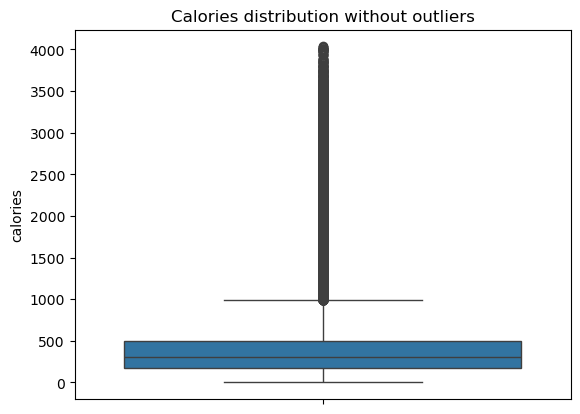

In [44]:
p = sns.boxplot(data = nutrition_table.drop(outliers_zscore)['calories'])
p.set_title('Calories distribution without outliers')

Text(0.5, 1.0, 'Fat distribution without outliers')

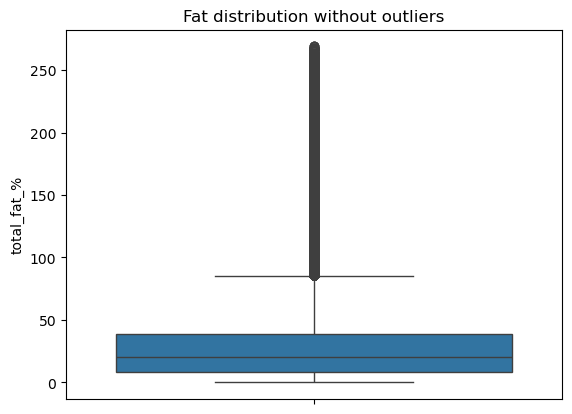

In [45]:
p = sns.boxplot(data = nutrition_table.drop(outliers_zscore)['total_fat_%'])
p.set_title('Fat distribution without outliers')

Text(0.5, 1.0, 'Sugar distribution without outliers')

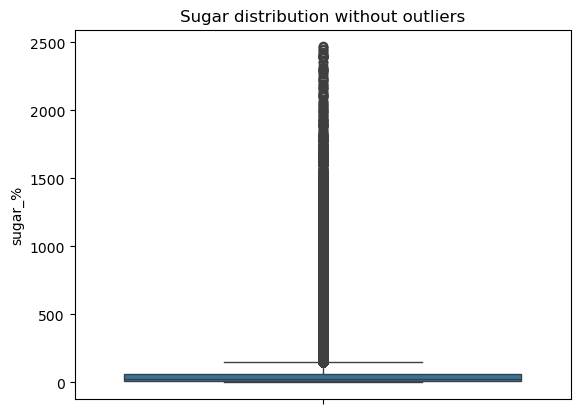

In [48]:
p = sns.boxplot(data = nutrition_table.drop(outliers_zscore)['sugar_%'])
p.set_title('Sugar distribution without outliers')

In [12]:
nutrition_table_normal = preprocessing(path, configs).normaldata
nutrition_table_normal

,dv_calories_%,dv_total_fat_%,dv_sugar_%,dv_sodium_%,dv_protein_%,dv_sat_fat_%,dv_carbs_%
0,2.575,0.000000,504.854369,0.000000,77.669903,0.000000,155.339806
1,8.670,207.612457,0.000000,196.078431,253.748558,403.690888,11.534025
2,13.490,163.083766,237.212750,355.819125,289.103039,200.148258,37.064492
3,18.405,92.366205,54.333062,10.866612,76.066286,43.466449,108.666123
4,17.645,5.667328,1909.889487,130.348541,17.001984,0.000000,158.685180
...,...,...,...,...,...,...,...
231632,20.760,125.240848,163.776493,125.240848,211.946050,101.156069,72.254335
231633,0.740,0.000000,270.270270,7837.837838,135.135135,0.000000,135.135135
231634,2.960,202.702703,67.567568,101.351351,202.702703,168.918919,0.000000
231635,9.400,117.021277,606.382979,117.021277,74.468085,223.404255,95.744681


In [17]:
# Calculer outliers par quantiles (IQR)

def detect_outliers_iqr(df):
    outliers = pd.DataFrame(index=df.index)  # DataFrame vide pour stocker les outliers
    
    for column in df.columns:
        print(column)
        Q1 = df[column].quantile(0.25)  # Premier quartile (25%)
        Q3 = df[column].quantile(0.75)  # Troisième quartile (75%)
        IQR = Q3 - Q1  # Calcul de l'IQR
        
        # Limites pour détecter les outliers
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        # Trouver les outliers : True si en dehors des limites, False sinon
        outliers[column] = (df[column] < lower_bound) | (df[column] > upper_bound)
        df = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
        
    print(df)
    return df, outliers

new_nutrition_table, outliers_iqr = detect_outliers_iqr(nutrition_table)
#print("Outliers détectés :")
#print(outliers_iqr)


calories
total_fat_%
sugar_%
sodium_%
protein_%
sat_fat_%
carbs_%
        calories  total_fat_%  sugar_%  sodium_%  protein_%  sat_fat_%  \
0           51.5          0.0     13.0       0.0        2.0        0.0   
1          173.4         18.0      0.0      17.0       22.0       35.0   
2          269.8         22.0     32.0      48.0       39.0       27.0   
3          368.1         17.0     10.0       2.0       14.0        8.0   
5          160.2         10.0     55.0       3.0        9.0       20.0   
...          ...          ...      ...       ...        ...        ...   
231632     415.2         26.0     34.0      26.0       44.0       21.0   
231633      14.8          0.0      2.0      58.0        1.0        0.0   
231634      59.2          6.0      2.0       3.0        6.0        5.0   
231635     188.0         11.0     57.0      11.0        7.0       21.0   
231636     174.9         14.0     33.0       4.0        4.0       11.0   

        carbs_%  
0           4.0  
1        

In [14]:
nutrition_table.shape[0] - 163298

68339

<Axes: >

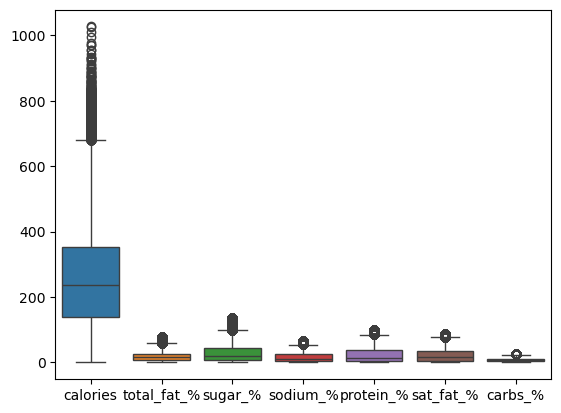

In [18]:
sns.boxplot(data=new_nutrition_table)

calories


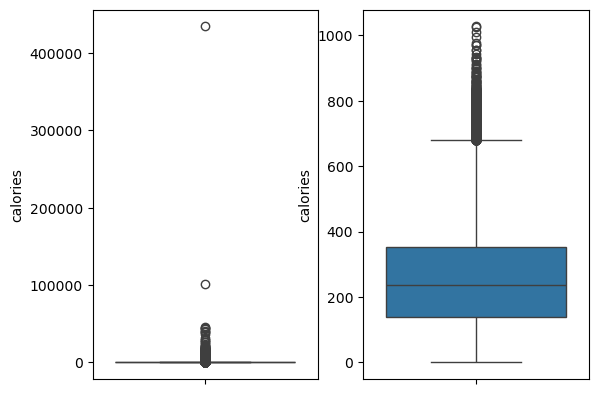

total_fat_%


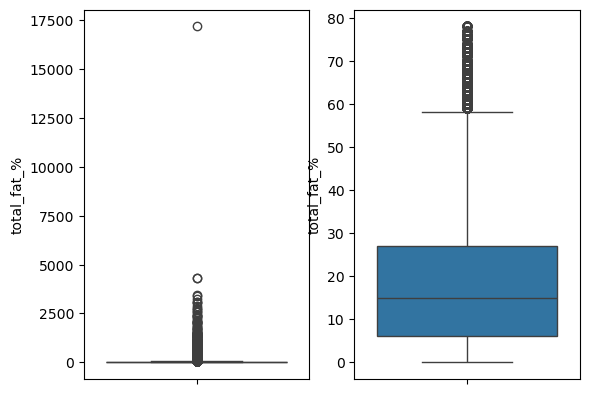

sugar_%


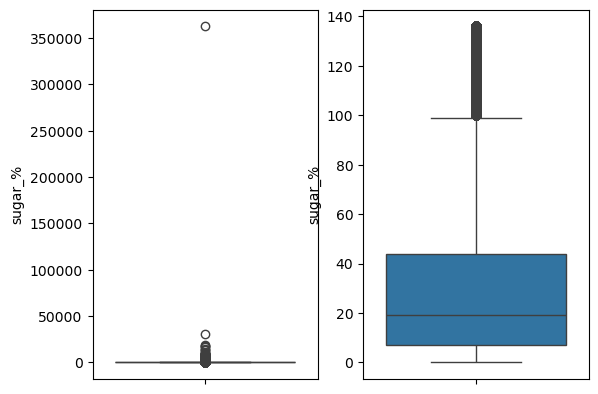

sodium_%


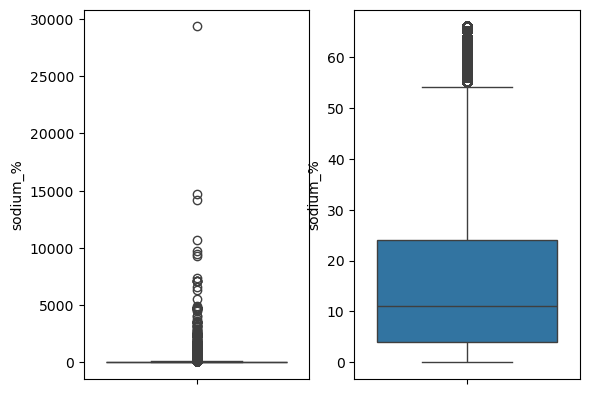

protein_%


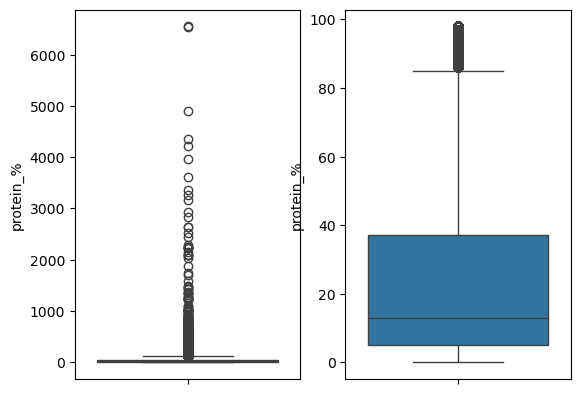

sat_fat_%


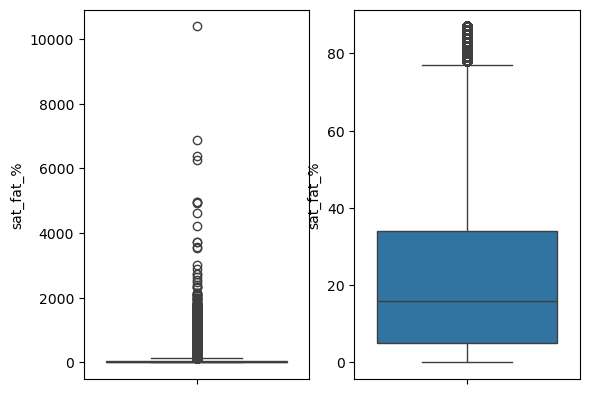

carbs_%


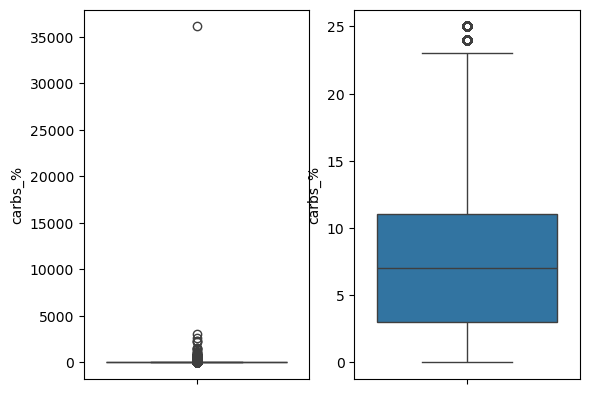

In [20]:
for column in nutrition_table.columns:
    print(column)
    fig, axes = plt.subplots(1, 2)
    sns.boxplot(ax=axes[0], data=nutrition_table[column])
    sns.boxplot(ax=axes[1], data=new_nutrition_table[column])
    plt.show()

In [4]:
# Tester à formatter nouveau score en A-E avec A la plus bonne qualité 
score = pd.read_csv('/Users/phuongnguyen/Documents/cours_BGD_Telecom_Paris_2024/Kit_Big_Data/dataset/score.csv', sep=',')
score

,id,dv_calories_%,dv_total_fat_%,dv_sugar_%,dv_sodium_%,dv_protein_%,dv_sat_fat_%,dv_carbs_%,nutriscore
0,137739,2.575,0.000000,504.854369,0.000000,77.669903,0.000000,155.339806,13.00
1,31490,8.670,207.612457,0.000000,196.078431,253.748558,403.690888,11.534025,10.75
2,112140,13.490,163.083766,237.212750,355.819125,289.103039,200.148258,37.064492,14.00
3,59389,18.405,92.366205,54.333062,10.866612,76.066286,43.466449,108.666123,13.00
4,44061,17.645,5.667328,1909.889487,130.348541,17.001984,0.000000,158.685180,12.00
...,...,...,...,...,...,...,...,...,...
231632,486161,20.760,125.240848,163.776493,125.240848,211.946050,101.156069,72.254335,9.00
231633,493372,0.740,0.000000,270.270270,7837.837838,135.135135,0.000000,135.135135,14.00
231634,308080,2.960,202.702703,67.567568,101.351351,202.702703,168.918919,0.000000,10.75
231635,298512,9.400,117.021277,606.382979,117.021277,74.468085,223.404255,95.744681,11.25


(array([7.0000e+00, 5.7000e+01, 5.9000e+02, 2.0110e+03, 7.5160e+03,
        1.3918e+04, 3.2910e+04, 4.3189e+04, 7.4302e+04, 5.7137e+04]),
 array([ 2.75 ,  3.875,  5.   ,  6.125,  7.25 ,  8.375,  9.5  , 10.625,
        11.75 , 12.875, 14.   ]),
 <BarContainer object of 10 artists>)

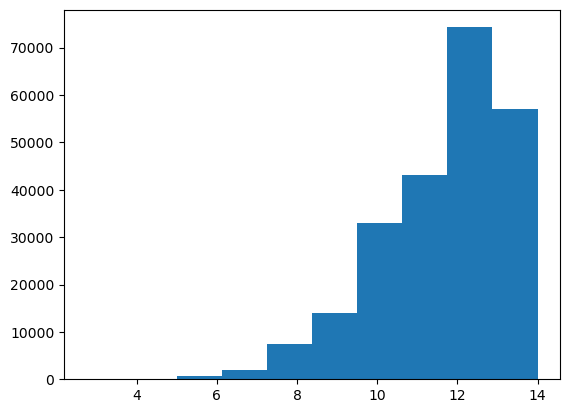

In [19]:
 # histogramme nutriscore

plt.hist(score['nutriscore'])

In [11]:
score['nutriscore'].describe()

count    231637.000000
mean         11.722237
std           1.726579
min           2.750000
25%          10.750000
50%          12.000000
75%          12.750000
max          14.000000
Name: nutriscore, dtype: float64

In [17]:
def set_scorelabel(score):
    label = np.empty(score.shape[0], dtype=str)
    label[np.where(score >= 12)] = 'A'
    label[np.where((score >= 9) & (score < 12))] = 'B'
    label[np.where((score >= 6) & (score < 9))] = 'C'
    label[np.where((score >= 3) & (score < 6))] = 'D'
    label[np.where(score < 3)] = 'E'
    return label

(array([1.22168e+05, 0.00000e+00, 9.32680e+04, 0.00000e+00, 0.00000e+00,
        1.57620e+04, 0.00000e+00, 4.38000e+02, 0.00000e+00, 1.00000e+00]),
 array([0. , 0.4, 0.8, 1.2, 1.6, 2. , 2.4, 2.8, 3.2, 3.6, 4. ]),
 <BarContainer object of 10 artists>)

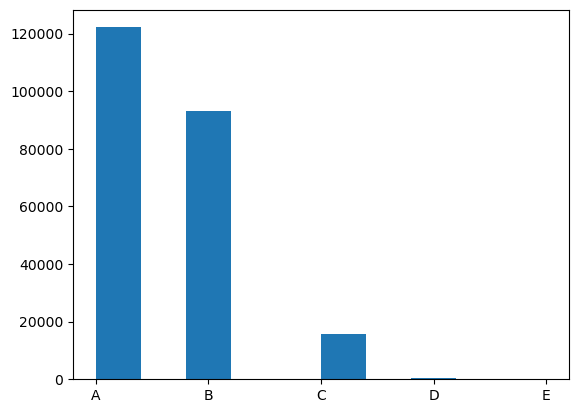

In [21]:
scores_labelled = set_scorelabel(score['nutriscore'])
plt.hist(scores_labelled)

In [ ]:
# Avant de passer dans un modèle de Machine Learning, il est important de traiter les données, faire des filtrages, essayer der résduire des aberants, présenter les étapes pas à pas
